# Dominant-soil-type aggregation — a single 10 km box, step by step

This notebook opens up the soil workflow described in `CLAUDE.md` on a **small
Brandenburg region (Oderbruch, 14.2–14.6 °E / 52.5–52.9 °N)** so every stage is
visible at native resolution:

1. **Download** the SoilGrids 250 m layers for the region into `outputs_demo/`.
2. **Identify agricultural 250 m pixels** — PROBA-V `Crops-CoverFraction` ≥ **80 %**
   (`soil.cropland_min_fraction`).
3. **Classify** every agricultural pixel by a **composite (topsoil, rooting-zone)
   texture class** — the USDA class of 0–5 cm paired with the USDA class of the
   thickness-weighted 5–100 cm texture, i.e. 12 × 12 = 144 possible codes
   (`soil.dominant_mode: usda_profile`) — and take the **majority per 10 km box**.
4. **Aggregate** only the dominant-class pixels, with the per-variable rule
   (arithmetic mean for texture, geometric mean for SOC, H⁺ mean for pH), and
   look at the spread (box-whiskers, standard deviation) **per depth layer**.
5. **Describe the three primary classes** per cell (§9) — the per-class mean,
   median, std and kurtosis the pipeline stores as intermediate NetCDF files,
   plus the class shares that quantify inter-class uncertainty.

Why two keys: a surface class alone cannot separate a uniform sand from a sandy
cover over loamy till — a sequence that is widespread in NE Germany and that
decides plant-available water. Pairing the topsoil class with the rooting-zone
class keeps those profiles apart while still masking on a *single* class, so
every depth is aggregated over the same set of pixels.

Everything is computed for **one 10 km box at a time**. Change `i` in §5
(`i = 0`, `i = 1`, …) and re-run from there to inspect a different box.
Downloads land in `outputs_demo/` (~1.6 MB for this region) and are cached.

All functions used here are the ones the pipeline itself calls
(`data4simplace.soil.dominant`, `data4simplace.soil.aggregate`), so the numbers
match what `data4simplace --config config.yaml` would export for these cells.

## 1. Setup — demo region & config

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle

import data4simplace
from data4simplace.config import load_config
from data4simplace.grid import TargetGrid, _standardise_lonlat_names
from data4simplace.soil.aggregate import bin_reduce, reducer_for
from data4simplace.soil.dominant import (
    USDA_CLASSES,
    dominant_class_per_cell,
    dominant_pixel_mask,
    profile_class_name,
    rootzone_mean,
    split_profile_class,
    usda_profile_class,
    usda_texture_class,
)
from data4simplace.soil.soilgrids import SoilGridsHandler
from data4simplace.spatial.cropland_weights import CroplandWeights

plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})

REPO = Path(data4simplace.__file__).resolve().parents[2]
DEMO = REPO / "outputs_demo"          # everything this notebook downloads lands here
DEMO.mkdir(exist_ok=True)

REGION = dict(min_lon=14.2, max_lon=14.6, min_lat=52.5, max_lat=52.9)  # Oderbruch
LAYERS = ["clay", "silt", "sand", "soc", "phh2o"]
DEPTHS = ["0-5cm", "5-15cm", "15-30cm", "30-60cm", "60-100cm", "100-200cm"]
TOPSOIL = DEPTHS[0]                    # first key of the composite class

# Start from the project config, then shrink it to the demo region so the
# thresholds/rules stay exactly the ones the pipeline uses.
cfg = load_config(REPO / "config.yaml").model_copy(deep=True)
for key, value in REGION.items():
    setattr(cfg.grid, key, value)
cfg.soil.layers = LAYERS
cfg.soil.depths = DEPTHS
cfg.soil.dominant_mode = "usda_profile"
cfg.paths.soilgrids_root = None            # ignore the shared tile root: download fresh
# The WCS cache is keyed by layer/depth only, so give each region its own folder
# -- otherwise changing REGION would silently reuse the previous region's tiles.
REGION_TAG = "_".join(f"{v:g}" for v in REGION.values())
TILES = DEMO / "soilgrids" / REGION_TAG
cfg.soil.wcs_cache_dir = TILES
cfg.paths.output_dir = DEMO

# Rooting zone: from the bottom of the topsoil layer to soil.rootzone_bottom_cm.
ROOTZONE = (5.0, cfg.soil.rootzone_bottom_cm)

grid = TargetGrid.from_config(cfg.grid)
cells = grid.cell_table()
print(f"demo grid: {grid.shape[0]} x {grid.shape[1]} = {len(cells)} boxes of "
      f"{grid.resolution_deg} deg (~10 km)")
print(f"cropland threshold: {cfg.soil.cropland_min_fraction:.0%} | "
      f"dominant_mode: {cfg.soil.dominant_mode}")
print(f"layers: {LAYERS}\ndepths: {DEPTHS}")
print(f"class keys: topsoil {TOPSOIL} x rooting zone "
      f"{ROOTZONE[0]:g}-{ROOTZONE[1]:g} cm")

demo grid: 4 x 4 = 16 boxes of 0.1 deg (~10 km)
cropland threshold: 80% | dominant_mode: usda_profile
layers: ['clay', 'silt', 'sand', 'soc', 'phh2o']
depths: ['0-5cm', '5-15cm', '15-30cm', '30-60cm', '60-100cm', '100-200cm']
class keys: topsoil 0-5cm x rooting zone 5-100 cm


## 2. Download the 250 m SoilGrids layers (all six depths)

`SoilGridsHandler.fetch_wcs` requests only the demo bounding box from the ISRIC
WCS and caches the GeoTIFF under `outputs_demo/soilgrids/<region>/`; a re-run
reuses the cache. Values are then **un-scaled** with the official SoilGrids
factors and reprojected to EPSG:4326 before anything else happens.

One extra step, `handler.mask_nodata`: the WCS GeoTIFFs carry **no nodata tag**
and write `0` over water and other gaps. Left in, a 0/0/0 texture pixel
classifies as USDA *sand* and votes in the majority, and a pH of 0 wrecks the H⁺
mean — so those pixels are masked. This is the same call the pipeline's
`SoilGridsHandler._load_fine` makes, reproduced here so the notebook matches the
production stack exactly.

In [2]:
handler = SoilGridsHandler(cfg)

# fine[layer][depth] -> 250 m DataArray. The first coverage loaded defines the
# pixel grid; everything else is reproject_match-ed onto it so the masks below
# apply unchanged to every layer and depth.
fine: dict[str, dict[str, xr.DataArray]] = {}
reference: xr.DataArray | None = None
for layer in LAYERS:
    fine[layer] = {}
    for depth in DEPTHS:
        raw = handler.fetch_wcs(layer, depth)      # -> TILES/<layer>_<depth>_mean.tif
        if raw is None:
            raise RuntimeError(f"could not fetch {layer} {depth} from the SoilGrids WCS")
        # unscale -> drop the 0 no-data sentinel -> reproject, exactly as the
        # pipeline's _load_fine does, so gap pixels never reach the class vote.
        da = handler.reproject(handler.mask_nodata(handler.unscale(raw, layer), layer))
        if reference is None:
            reference = da
        else:
            da = da.rio.reproject_match(reference)
        fine[layer][depth] = _standardise_lonlat_names(da).load()

top = {layer: fine[layer][TOPSOIL] for layer in LAYERS}   # first class key

pix_deg = float(np.abs(np.diff(top["clay"].lon.values)).mean())
nodata = float(np.mean(~np.isfinite(top["clay"].values)) * 100)
tiles = sorted(TILES.glob("*.tif"))
print(f"250 m stack: {len(LAYERS)} layers x {len(DEPTHS)} depths, "
      f"{tuple(top['clay'].shape)} pixels each, "
      f"{pix_deg:.5f} deg (~{pix_deg * 111e3:.0f} m)")
print(f"no-data (0 sentinel) pixels dropped: {nodata:.1f}% (topsoil)")
print(f"{len(tiles)} tiles cached in {TILES.relative_to(REPO)} "
      f"({sum(p.stat().st_size for p in tiles) / 1e6:.1f} MB total)")

250 m stack: 5 layers x 6 depths, (251, 265) pixels each, 0.00226 deg (~251 m)
no-data (0 sentinel) pixels dropped: 3.8% (topsoil)
30 tiles cached in outputs_demo/soilgrids/14.2_14.6_52.5_52.9 (1.6 MB total)


## 3. Identify the agricultural 250 m pixels (cover ≥ 80 %)

The PROBA-V LC100 `Crops-CoverFraction` layer is 100 m, so it is clipped to the
region (saved to `outputs_demo/` for reference), resampled onto the **SoilGrids
250 m pixel grid**, and thresholded at `soil.cropland_min_fraction`. This is a
hard filter: a 250 m pixel is either agricultural or it is dropped — no partial
weighting downstream.

In [3]:
weights = CroplandWeights(cfg)

frac100 = weights.load_fraction()                  # native 100 m, clipped to the region
frac100.rio.to_raster(DEMO / "cropland_fraction_100m.tif")

frac250 = _standardise_lonlat_names(weights.align_to(reference)).load()   # 100 m -> 250 m
keep_ag = _standardise_lonlat_names(weights.keep_mask(reference)).load()  # >= 80 % -> True

n_ag, n_tot = int(keep_ag.sum()), int(keep_ag.size)
n_nodata_ag = int((~np.isfinite(top["clay"].values) & keep_ag.values).sum())
print(f"agricultural 250 m pixels: {n_ag} / {n_tot} ({100 * n_ag / n_tot:.1f}%) "
      f"at cover >= {cfg.soil.cropland_min_fraction:.0%}")
print(f"  of these, SoilGrids has no data for {n_nodata_ag} (masked in step 2; see §9)")
print(f"saved {DEMO / 'cropland_fraction_100m.tif'} "
      f"({(DEMO / 'cropland_fraction_100m.tif').stat().st_size / 1e6:.1f} MB, "
      f"{tuple(frac100.shape)} px)")

agricultural 250 m pixels: 24207 / 66515 (36.4%) at cover >= 80%
  of these, SoilGrids has no data for 26 (masked in step 2; see §9)
saved /data01/FDS/muduchuru/codes/GITHUB/data4simplace/outputs_demo/cropland_fraction_100m.tif (1.5 MB, (605, 606) px)


## 4. Classify each agricultural pixel: topsoil × rooting zone

Two keys per 250 m pixel:

- **topsoil class** — `usda_texture_class` on the 0–5 cm sand/silt/clay;
- **rooting-zone class** — the same triangle applied to `rootzone_mean`, the
  *thickness-weighted* mean texture over 5–100 cm (weights 10, 15, 30, 40 cm for
  the four layers in the window; a layer that only partly overlaps contributes
  only its overlapping thickness).

`usda_profile_class` packs the pair into one code, `(topsoil − 1)·12 + rootzone`,
so a pixel is only pooled with pixels that match **both** at the surface and
through the rooting zone. Non-agricultural pixels are set to `0` (unclassified)
so they cannot vote. `dominant_class_per_cell` then takes the majority composite
class inside each 10 km box, and `dominant_pixel_mask` keeps only those pixels.

The third panel maps the **composite classes themselves** — 144 are possible,
but only a handful occur here — labelled `topsoil/rooting-zone` in standard USDA
shorthand (`SL/SL` = sandy loam throughout, `L/CL` = loam over clay loam). The
same colours are reused for the box figures below.

agricultural pixels classified: 24181
  topsoil class != rooting-zone class: 4795 (19.8%)
  distinct composite classes in the region: 17 of 144 possible


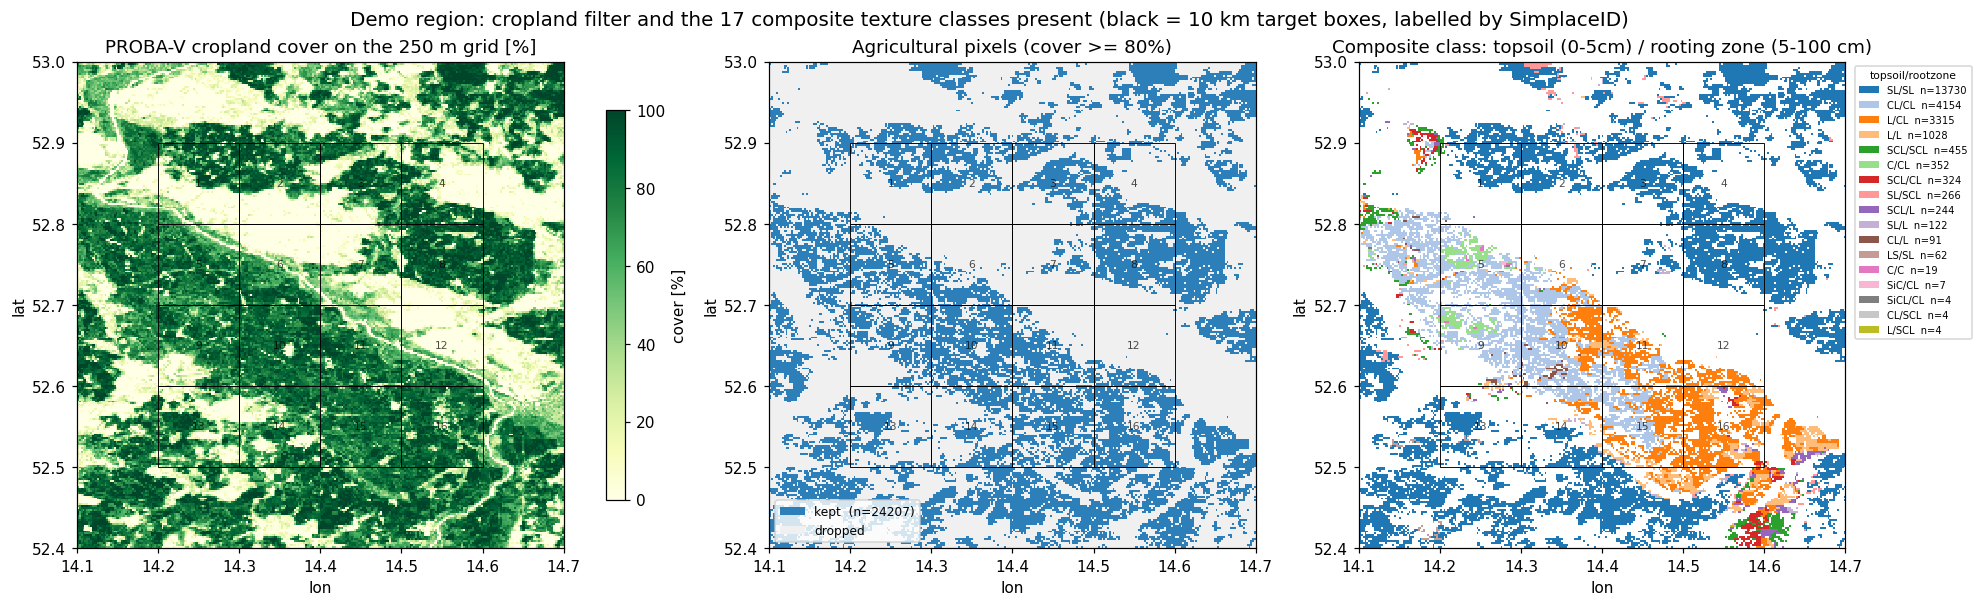

                composite class    abbr  code  layered  pixels  share_%
          sandy_loam/sandy_loam   SL/SL   118    False   13730    56.78
            clay_loam/clay_loam   CL/CL    40    False    4154    17.18
                 loam/clay_loam    L/CL    76     True    3315    13.71
                      loam/loam     L/L    79    False    1028     4.25
sandy_clay_loam/sandy_clay_loam SCL/SCL    66    False     455     1.88
                 clay/clay_loam    C/CL     4     True     352     1.46
      sandy_clay_loam/clay_loam  SCL/CL    64     True     324     1.34
     sandy_loam/sandy_clay_loam  SL/SCL   114     True     266     1.10
           sandy_clay_loam/loam   SCL/L    67     True     244     1.01
                sandy_loam/loam    SL/L   115     True     122     0.50
                 clay_loam/loam    CL/L    43     True      91     0.38
          loamy_sand/sandy_loam   LS/SL   130     True      62     0.26
                      clay/clay     C/C     1    False      19  

In [4]:
cls_top = usda_texture_class(top["sand"], top["silt"], top["clay"])
rz = {t: rootzone_mean(fine[t], *ROOTZONE) for t in ("sand", "silt", "clay")}
cls_root = usda_texture_class(rz["sand"], rz["silt"], rz["clay"])

cls_profile = usda_profile_class(cls_top, cls_root)     # 12 x 12 composite code
cls_ag = cls_profile.where(keep_ag, 0).astype("int16")  # only cropland pixels vote

dominant = dominant_class_per_cell(cls_ag, grid)        # one composite class per box
keep_dom = dominant_pixel_mask(cls_ag, dominant)        # 250 m keep-mask

tab20 = plt.get_cmap("tab20")
usda_colors = {c: tab20((c - 1) % 20) for c in USDA_CLASSES}
# Standard USDA shorthand, for compact axis labels ("CL/C" = clay loam over clay).
USDA_ABBR = {1: "C", 2: "SiC", 3: "SC", 4: "CL", 5: "SiCL", 6: "SCL",
             7: "L", 8: "SiL", 9: "Si", 10: "SL", 11: "LS", 12: "S"}
abbr = lambda code: "/".join(USDA_ABBR[c] for c in split_profile_class(code))

# How often do the two keys disagree? That disagreement is what the second key
# adds over plain 'usda' mode.
ag = keep_ag.values & (cls_ag.values > 0)
differ = int((cls_top.values[ag] != cls_root.values[ag]).sum())

# Region-wide composite classes, most frequent first; this palette is reused by
# every later figure so a class keeps its colour throughout the notebook.
comp_order, comp_pixels = np.unique(cls_ag.values[ag], return_counts=True)
srt = np.argsort(-comp_pixels)
comp_order, comp_pixels = comp_order[srt], comp_pixels[srt]
comp_colors = {c: tab20(k % 20) for k, c in enumerate(comp_order)}

print(f"agricultural pixels classified: {int(ag.sum())}")
print(f"  topsoil class != rooting-zone class: {differ} "
      f"({100 * differ / max(ag.sum(), 1):.1f}%)")
print(f"  distinct composite classes in the region: {comp_order.size} of 144 possible")


def imshow_da(ax, da, **kw):
    # imshow a lat/lon DataArray using its own coordinates as the extent.
    lon, lat = da.lon.values, da.lat.values
    half_x = abs(lon[1] - lon[0]) / 2 if lon.size > 1 else 0.0
    half_y = abs(lat[1] - lat[0]) / 2 if lat.size > 1 else 0.0
    extent = [lon.min() - half_x, lon.max() + half_x,
              lat.min() - half_y, lat.max() + half_y]
    return ax.imshow(da.values, extent=extent, origin="upper",
                     interpolation="nearest", **kw)


def draw_boxes(ax, labels=True):
    # Outline the 10 km target cells and label them with their SimplaceID.
    h = grid.resolution_deg / 2
    for _, c in cells.iterrows():
        ax.add_patch(Rectangle((c.lon - h, c.lat - h), 2 * h, 2 * h,
                               fill=False, ec="black", lw=0.6))
        if labels:
            ax.text(c.lon, c.lat, int(c.SimplaceID), ha="center", va="center",
                    fontsize=7, color="black", alpha=0.7)


def class_panel(ax, class_da, title, colors, namer, codes=None, legend_kw=None):
    # Categorical map of a class field, with a legend of the classes shown.
    if codes is None:
        codes = sorted(c for c in np.unique(class_da.values) if c > 0)
    idx = np.full(class_da.shape, np.nan)
    for k, c in enumerate(codes):
        idx[class_da.values == c] = k
    imshow_da(ax, xr.DataArray(idx, dims=class_da.dims, coords=class_da.coords),
              cmap=ListedColormap([colors[c] for c in codes]),
              vmin=-0.5, vmax=len(codes) - 0.5)
    ax.set_title(title)
    ax.legend(handles=[Patch(facecolor=colors[c], label=namer(c)) for c in codes],
              **{"fontsize": 7, "loc": "lower left", **(legend_kw or {})})
    return codes


fig, axes = plt.subplots(1, 3, figsize=(18, 5.4), constrained_layout=True)
im = imshow_da(axes[0], frac250 * 100, cmap="YlGn", vmin=0, vmax=100)
axes[0].set_title("PROBA-V cropland cover on the 250 m grid [%]")
fig.colorbar(im, ax=axes[0], shrink=0.8, label="cover [%]")

imshow_da(axes[1], keep_ag.astype(float), cmap=ListedColormap(["#f0f0f0", "#2c7fb8"]),
          vmin=0, vmax=1)
axes[1].set_title(f"Agricultural pixels (cover >= {cfg.soil.cropland_min_fraction:.0%})")
axes[1].legend(handles=[Patch(facecolor="#2c7fb8", label=f"kept  (n={n_ag})"),
                        Patch(facecolor="#f0f0f0", label="dropped")],
               fontsize=8, loc="lower left")

class_panel(axes[2], cls_ag,
            f"Composite class: topsoil ({TOPSOIL}) / rooting zone "
            f"({ROOTZONE[0]:g}-{ROOTZONE[1]:g} cm)",
            comp_colors,
            lambda c: f"{abbr(c)}  n={int(comp_pixels[list(comp_order).index(c)])}",
            codes=list(comp_order),
            legend_kw={"fontsize": 6.5, "loc": "upper left",
                       "bbox_to_anchor": (1.01, 1.0), "title": "topsoil/rootzone",
                       "title_fontsize": 7})

for ax in axes:
    draw_boxes(ax)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
fig.suptitle(f"Demo region: cropland filter and the {comp_order.size} composite "
             f"texture classes present "
             f"(black = 10 km target boxes, labelled by SimplaceID)", fontsize=13)
plt.show()

region_classes = pd.DataFrame({
    "composite class": [profile_class_name(c) for c in comp_order],
    "abbr": [abbr(c) for c in comp_order],
    "code": comp_order,
    "layered": [split_profile_class(c)[0] != split_profile_class(c)[1]
                for c in comp_order],
    "pixels": comp_pixels,
    "share_%": (100 * comp_pixels / comp_pixels.sum()).round(2),
})
print(region_classes.to_string(index=False))
print("\nUSDA shorthand: "
      + ", ".join(f"{USDA_ABBR[c]}={USDA_CLASSES[c]}"
                  for c in sorted({p for code in comp_order
                                   for p in split_profile_class(code)})))

## 5. Pick one 10 km box

Boxes are ranked by how instructive they are — first by how many composite
classes hold at least 5 agricultural pixels, then by pixel count.

> **Change `i` below (`i = 0`, `i = 1`, …) and re-run from here** to walk through
> the same analysis for another box. `i` indexes the ranked table; you can also
> set `BOX_ID` to a SimplaceID directly.

In [5]:
i = 0          # <-- try i = 1, i = 2, ... to analyse a different 10 km box
BOX_ID = None  # <-- or set a SimplaceID (see the map above) to override the ranking


def box_bounds(cell):
    h = grid.resolution_deg / 2
    return cell.lon - h, cell.lon + h, cell.lat - h, cell.lat + h


def clip_box(da, bounds):
    # Subset a fine field to one 10 km box (works for either lat ordering).
    lon0, lon1, lat0, lat1 = bounds
    sub = da.where((da.lon >= lon0) & (da.lon < lon1)
                   & (da.lat >= lat0) & (da.lat < lat1), drop=True)
    # ``where`` promotes booleans to float; restore the mask dtype.
    return sub.fillna(0).astype(bool) if da.dtype == bool else sub


rows = []
for _, cell in cells.iterrows():
    sub = clip_box(cls_ag, box_bounds(cell)).values
    codes, counts = np.unique(sub[sub > 0], return_counts=True)
    dom = int(dominant.sel(lat=cell.lat, lon=cell.lon, method="nearest"))
    dom_top, dom_root = split_profile_class(dom)
    rows.append({"SimplaceID": int(cell.SimplaceID), "lat": cell.lat, "lon": cell.lon,
                 "ag_pixels": int(counts.sum()), "classes": len(codes),
                 # composite classes big enough to plot a distribution for
                 "classes_5px": int((counts >= 5).sum()),
                 "dominant": profile_class_name(dom),
                 "layered": dom_top != dom_root,
                 "dominant_share_%": round(100 * counts.max() / counts.sum(), 1)
                 if counts.size else np.nan})
ranked = (pd.DataFrame(rows).sort_values(["classes_5px", "ag_pixels"], ascending=False)
          .reset_index(drop=True))
print(ranked.to_string())

sel_id = int(BOX_ID if BOX_ID is not None else ranked.loc[i, "SimplaceID"])
cell = cells[cells.SimplaceID == sel_id].iloc[0]
bounds = box_bounds(cell)
dom_class = int(dominant.sel(lat=cell.lat, lon=cell.lon, method="nearest"))
dom_top, dom_root = split_profile_class(dom_class)

box_frac100 = clip_box(_standardise_lonlat_names(frac100), bounds)
box_frac = clip_box(frac250, bounds)
box_keep = clip_box(keep_ag, bounds)
box_top = clip_box(cls_top.where(keep_ag, 0), bounds)
box_root = clip_box(cls_root.where(keep_ag, 0), bounds)
box_cls = clip_box(cls_ag, bounds)
box_dom = clip_box(keep_dom, bounds)
box = {layer: clip_box(da, bounds) for layer, da in top.items()}          # topsoil
box_depth = {layer: {d: clip_box(da, bounds) for d, da in depths.items()}
             for layer, depths in fine.items()}                          # all depths

print(f"\n--- box i={i}: SimplaceID {sel_id} @ ({cell.lat:.2f} N, {cell.lon:.2f} E) ---")
print(f"250 m pixels in box      : {box_cls.size}")
print(f"agricultural (>= {cfg.soil.cropland_min_fraction:.0%})   : {int(box_keep.sum())} "
      f"({int((box_cls > 0).sum())} of them with valid SoilGrids data)")
print(f"dominant composite class : {profile_class_name(dom_class)} (code {dom_class}) "
      f"-> {int(box_dom.sum())} pixels aggregated")
print(f"  topsoil key            : {USDA_CLASSES[dom_top]}")
print(f"  rooting-zone key       : {USDA_CLASSES[dom_root]}"
      f"{'  (layered profile)' if dom_top != dom_root else '  (same as topsoil)'}")

    SimplaceID    lat    lon  ag_pixels  classes  classes_5px               dominant  layered  dominant_share_%
0            5  52.75  14.25        856       10            6    clay_loam/clay_loam    False              73.0
1           13  52.55  14.25        475        8            6  sandy_loam/sandy_loam    False              86.5
2           16  52.55  14.55       1180        6            5         loam/clay_loam     True              78.3
3           15  52.55  14.45       1161        5            5         loam/clay_loam     True              53.5
4            9  52.65  14.25        749       10            5    clay_loam/clay_loam    False              74.6
5           14  52.55  14.35        694        6            5  sandy_loam/sandy_loam    False              48.3
6           10  52.65  14.35       1318        4            4    clay_loam/clay_loam    False              61.0
7            6  52.75  14.35        407        8            4    clay_loam/clay_loam    False           

## 6. Inside the box: cropland filter → two keys → dominant composite class

Four views of the same 10 km box: the raw 100 m cover fraction, the 250 m
resampled fraction with the ≥ 80 % pixels outlined, the composite classes of the
agricultural pixels (same colours as the region map), and the pixels that survive
the dominant-class mask — the only ones that reach the aggregation step.

The contingency table underneath is the 12 × 12 grid made concrete: rows are
topsoil classes, columns rooting-zone classes, cells are pixel counts. Off-
diagonal mass is what plain `usda` mode would have merged.

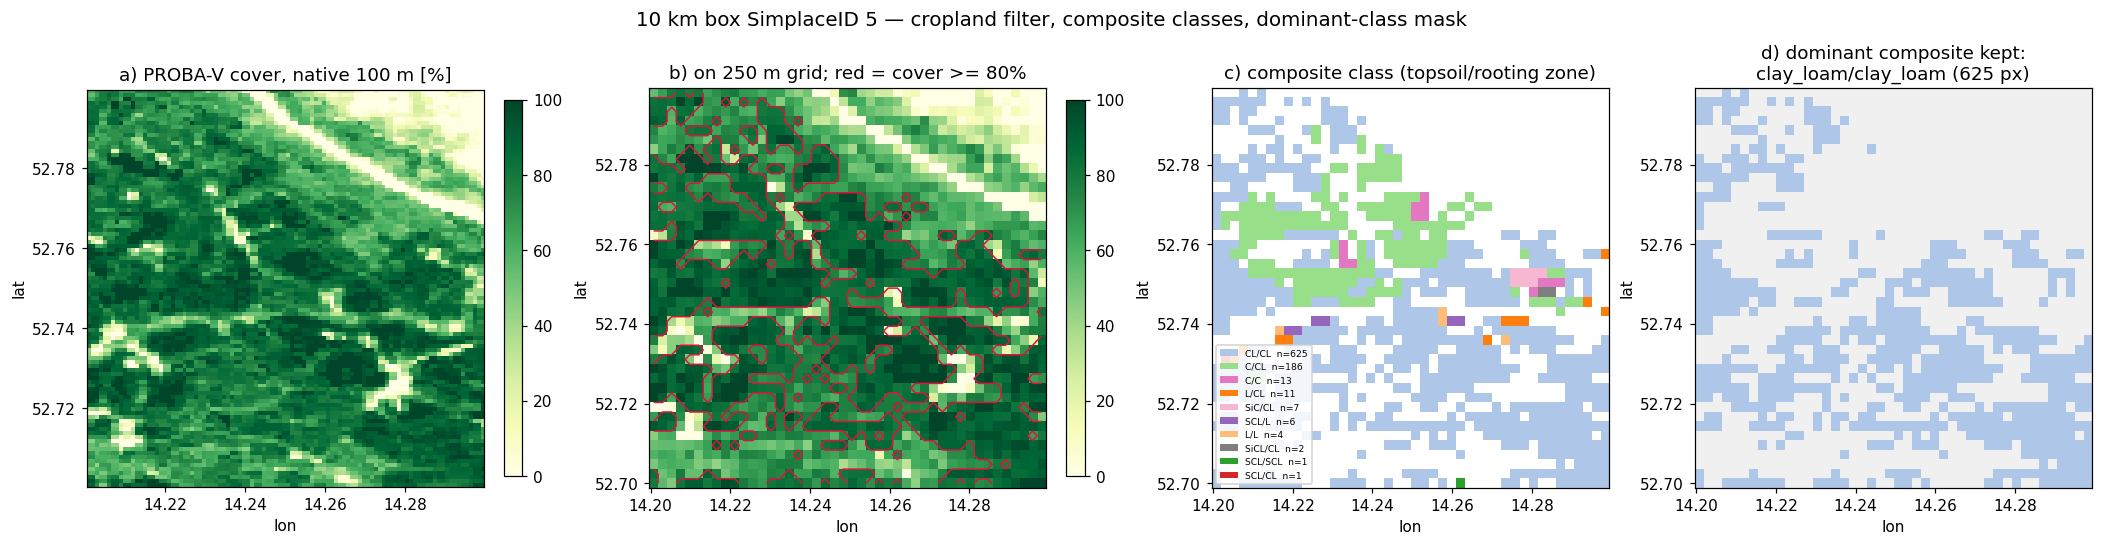

pixel counts, topsoil class x rooting-zone class:
rooting zone     clay  clay_loam  loam  sandy_clay_loam
topsoil                                                
clay               13        186     0                0
clay_loam           0        625     0                0
loam                0         11     4                0
sandy_clay_loam     0          1     6                1
silty_clay          0          7     0                0
silty_clay_loam     0          2     0                0

composite-class composition of the agricultural pixels in this box:
                                 pixels  share_%
clay_loam/clay_loam                 625     73.0
clay/clay_loam                      186     21.7
clay/clay                            13      1.5
loam/clay_loam                       11      1.3
silty_clay/clay_loam                  7      0.8
sandy_clay_loam/loam                  6      0.7
loam/loam                             4      0.5
silty_clay_loam/clay_loam             2  

In [6]:
box_codes, box_counts = np.unique(box_cls.values[box_cls.values > 0], return_counts=True)
order = box_codes[np.argsort(-box_counts)]
counts = pd.Series(box_counts[np.argsort(-box_counts)], index=order)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.9), constrained_layout=True)

im = imshow_da(axes[0], box_frac100 * 100, cmap="YlGn", vmin=0, vmax=100)
axes[0].set_title("a) PROBA-V cover, native 100 m [%]")
fig.colorbar(im, ax=axes[0], shrink=0.8)

im = imshow_da(axes[1], box_frac * 100, cmap="YlGn", vmin=0, vmax=100)
axes[1].contour(box_keep.lon, box_keep.lat, box_keep.astype(float).values,
                levels=[0.5], colors="crimson", linewidths=1.0)
axes[1].set_title(f"b) on 250 m grid; red = cover >= "
                  f"{cfg.soil.cropland_min_fraction:.0%}")
fig.colorbar(im, ax=axes[1], shrink=0.8)

class_panel(axes[2], box_cls, "c) composite class (topsoil/rooting zone)",
            comp_colors, lambda c: f"{abbr(c)}  n={int(counts[c])}",
            codes=list(order), legend_kw={"fontsize": 6, "framealpha": 0.85})

imshow_da(axes[3], box_dom.astype(float),
          cmap=ListedColormap(["#f0f0f0", comp_colors[dom_class]]), vmin=0, vmax=1)
axes[3].set_title(f"d) dominant composite kept:\n{profile_class_name(dom_class)} "
                  f"({int(box_dom.sum())} px)")

for ax in axes:
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
fig.suptitle(f"10 km box SimplaceID {sel_id} — cropland filter, composite "
             f"classes, dominant-class mask", fontsize=13)
plt.show()

valid = box_cls.values > 0
crosstab = pd.crosstab(
    pd.Series([USDA_CLASSES[c] for c in box_top.values[valid].astype(int)],
              name="topsoil"),
    pd.Series([USDA_CLASSES[c] for c in box_root.values[valid].astype(int)],
              name="rooting zone"),
)
print("pixel counts, topsoil class x rooting-zone class:")
print(crosstab.to_string())

composition = pd.DataFrame({
    "pixels": counts.values,
    "share_%": (100 * counts / counts.sum()).round(1).values,
}, index=[profile_class_name(c) for c in order])
print("\ncomposite-class composition of the agricultural pixels in this box:")
print(composition.to_string())

## 7. Box-and-whisker

### 7a. Topsoil: how the distribution depends on the composite class

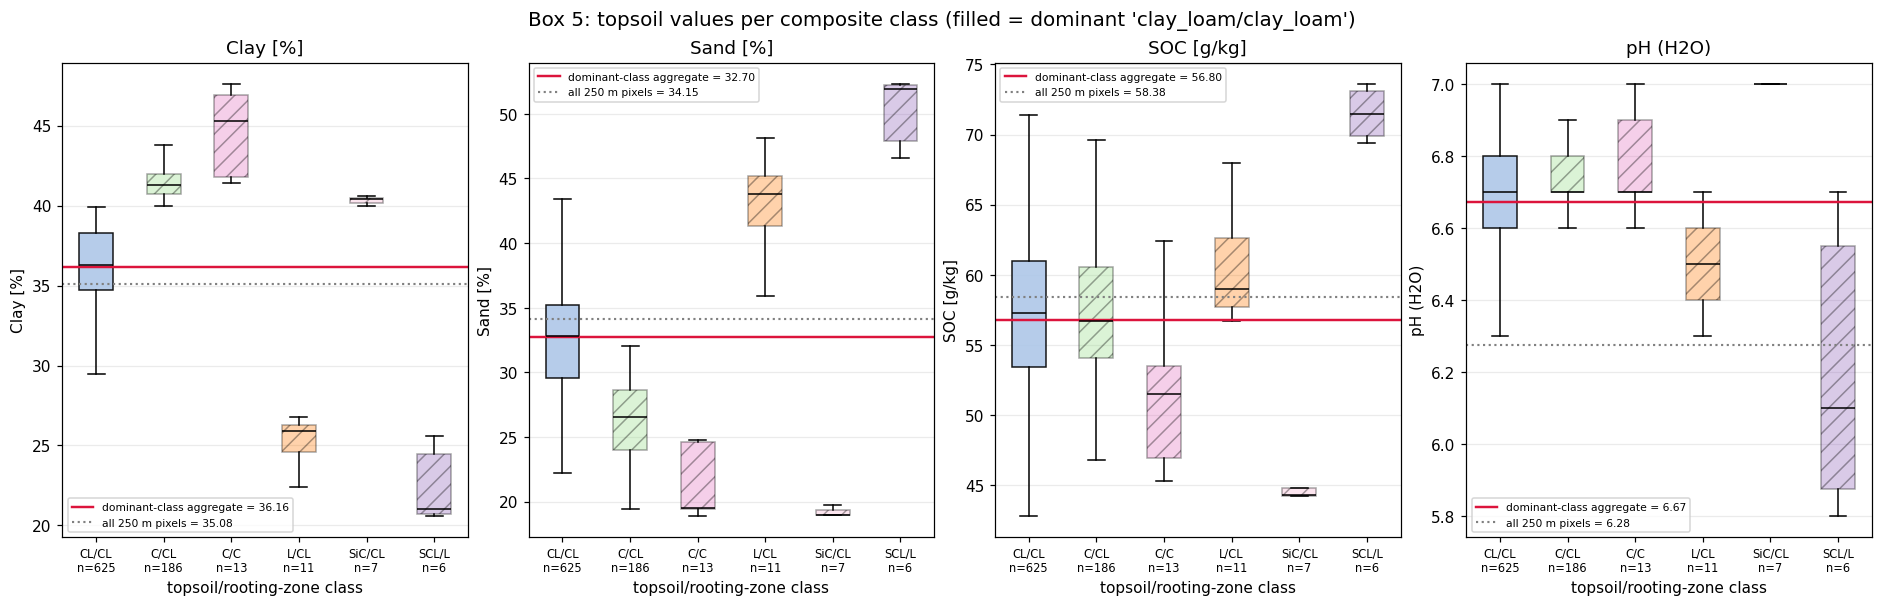

4 class(es) with < 5 pixels not plotted (8 px): loam/loam, silty_clay_loam/clay_loam, sandy_clay_loam/sandy_clay_loam, sandy_clay_loam/clay_loam


In [7]:
PANELS = [("clay", "Clay [%]"), ("sand", "Sand [%]"),
          ("soc", "SOC [g/kg]"), ("phh2o", "pH (H2O)")]

# Classes with a handful of pixels say little in a boxplot: show those with
# >= 5 pixels (the dominant one always) and report the remainder as a count.
plot_order = [c for c in order if counts[c] >= 5 or c == dom_class]
dropped = counts.drop(plot_order, errors="ignore")

fig, axes = plt.subplots(1, 4, figsize=(17, 5.4), constrained_layout=True)
for ax, (layer, title) in zip(axes, PANELS):
    da = box[layer]
    groups, labels = [], []
    for c in plot_order:
        v = da.values[(box_cls.values == c) & np.isfinite(da.values)]
        groups.append(v)
        labels.append(f"{abbr(c)}\nn={v.size}")

    bp = ax.boxplot(groups, patch_artist=True, showfliers=False,
                    medianprops={"color": "black"})
    for patch, c in zip(bp["boxes"], plot_order):
        patch.set_facecolor(comp_colors[c])
        if c == dom_class:
            patch.set_alpha(0.9)
        else:
            patch.set_alpha(0.35); patch.set_hatch("//")

    reduce = reducer_for(layer)
    v_dom = da.values[box_dom.values & np.isfinite(da.values)]
    v_all = da.values[np.isfinite(da.values)]
    ax.axhline(reduce(v_dom), color="crimson", lw=1.6,
               label=f"dominant-class aggregate = {reduce(v_dom):.2f}")
    ax.axhline(reduce(v_all), color="grey", lw=1.4, ls=":",
               label=f"all 250 m pixels = {reduce(v_all):.2f}")

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_xlabel("topsoil/rooting-zone class")
    ax.set_title(title); ax.set_ylabel(title)
    ax.legend(fontsize=7, loc="best")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(f"Box {sel_id}: topsoil values per composite class "
             f"(filled = dominant '{profile_class_name(dom_class)}')", fontsize=13)
plt.show()

if len(dropped):
    print(f"{len(dropped)} class(es) with < 5 pixels not plotted "
          f"({int(dropped.sum())} px): {', '.join(profile_class_name(c) for c in dropped.index)}")

### 7b. Depth-wise spread of the dominant-class pixels

The composite class is chosen once — topsoil texture plus rooting-zone texture —
and the resulting mask is applied to **every depth**, so the same 250 m pixels
are aggregated all the way down the profile. These panels show, for box `i`, the
distribution of each property across those pixels at each of the six SIMPLACE
depth layers:

- **boxes** — the 250 m spread within the box (median, IQR, whiskers);
- **σ** — the standard deviation of the same pixels, i.e. the sub-grid
  variability the single exported value has to stand in for;
- **red line** — the aggregated value per depth, which is what the export writes
  into `<stem>_1 … <stem>_6`.

Because the second key already constrains 5–100 cm texture, the σ of clay and
sand should stay comparable with depth; a σ that blows up below 100 cm is
expected — that depth is outside the classification window.

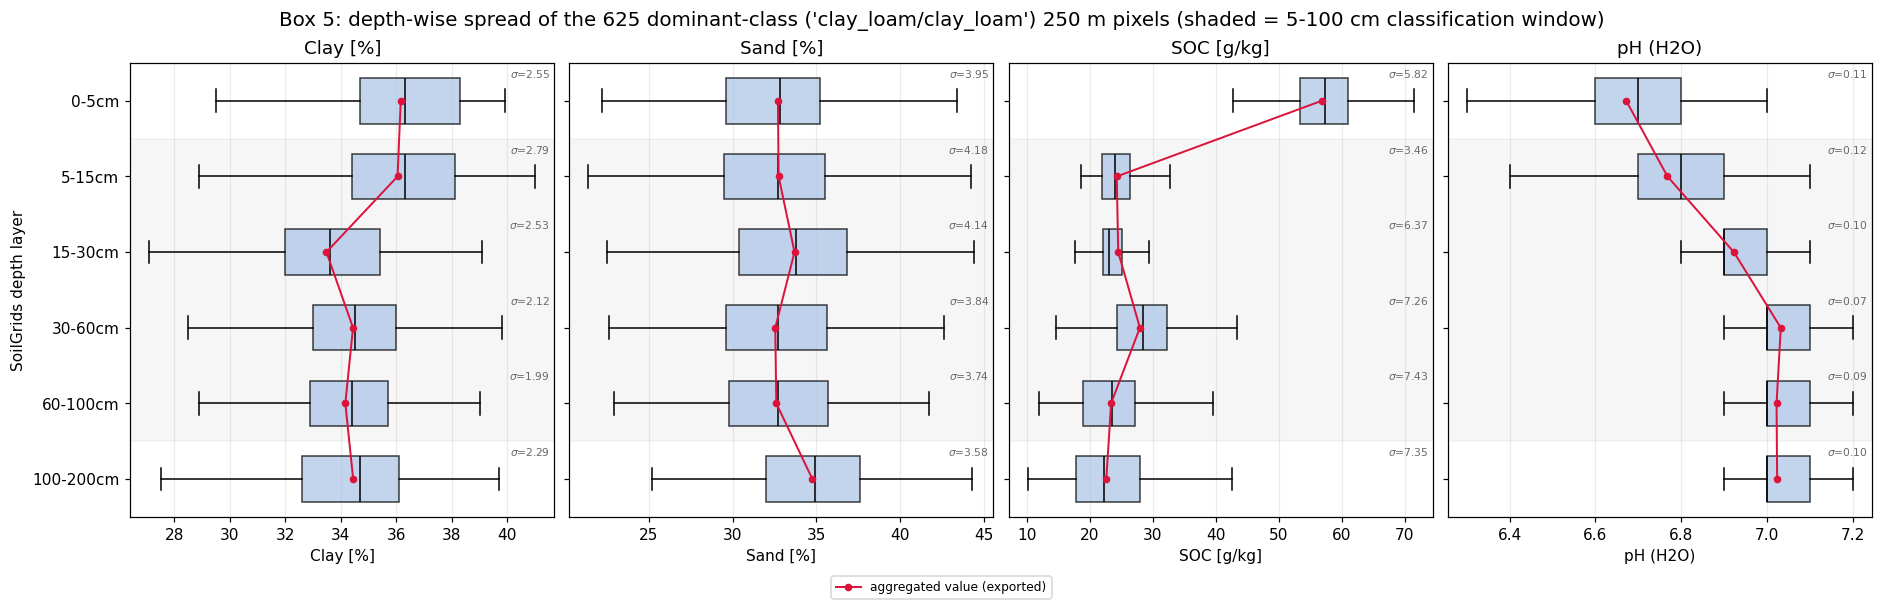

                mean                                 std                     
property        clay  phh2o       sand        soc   clay  phh2o   sand    soc
depth                                                                        
0-5cm      36.155998  6.687  32.701000  57.098999  2.549  0.110  3.945  5.823
5-15cm     36.041000  6.786  32.743000  24.521999  2.792  0.118  4.181  3.459
15-30cm    33.478001  6.935  33.692001  25.135000  2.525  0.096  4.140  6.365
30-60cm    34.436001  7.039  32.542000  28.809999  2.119  0.075  3.838  7.256
60-100cm   34.159000  7.032  32.604000  24.403000  1.987  0.088  3.741  7.435
100-200cm  34.442001  7.036  34.752998  23.726000  2.288  0.099  3.579  7.346

full per-depth statistics:
                    n_pixels       mean    std       cv_%  aggregate
property depth                                                      
clay     0-5cm           625  36.155998  2.549   7.049000     36.156
         5-15cm          625  36.041000  2.792   7.746000     3

In [8]:
DEPTH_POS = np.arange(1, len(DEPTHS) + 1)

fig, axes = plt.subplots(1, 4, figsize=(17, 5.4), sharey=True, constrained_layout=True)
records = []
for ax, (layer, title) in zip(axes, PANELS):
    groups, aggs = [], []
    for depth in DEPTHS:
        da = box_depth[layer][depth]
        v = da.values[box_dom.values & np.isfinite(da.values)]
        agg = reducer_for(layer)(v) if v.size else np.nan
        groups.append(v)
        aggs.append(agg)
        records.append({"property": layer, "depth": depth, "n_pixels": v.size,
                        "mean": np.mean(v) if v.size else np.nan,
                        "std": np.std(v, ddof=1) if v.size > 1 else np.nan,
                        "cv_%": (100 * np.std(v, ddof=1) / np.mean(v))
                        if v.size > 1 and np.mean(v) else np.nan,
                        "aggregate": agg})

    bp = ax.boxplot(groups, vert=False, positions=DEPTH_POS, patch_artist=True,
                    showfliers=False, widths=0.6, medianprops={"color": "black"})
    for patch in bp["boxes"]:
        patch.set_facecolor(comp_colors[dom_class]); patch.set_alpha(0.75)
    ax.plot(aggs, DEPTH_POS, "o-", color="crimson", ms=4, lw=1.3, zorder=3,
            label="aggregated value (exported)" if layer == PANELS[0][0] else None)
    for pos, v in zip(DEPTH_POS, groups):
        if v.size > 1:
            ax.text(0.99, pos - 0.36, f"$\sigma$={np.std(v, ddof=1):.2f}",
                    transform=ax.get_yaxis_transform(), ha="right", va="center",
                    fontsize=7, color="dimgrey")
    ax.set_xlabel(title); ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)

axes[0].set_yticks(DEPTH_POS)
axes[0].set_yticklabels(DEPTHS)
axes[0].set_ylabel("SoilGrids depth layer")
axes[0].invert_yaxis()
# Mark the depth window the rooting-zone key was computed over.
for ax in axes:
    ax.axhspan(1.5, 5.5, color="grey", alpha=0.07, zorder=0)
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           fontsize=8, ncol=2)
fig.suptitle(f"Box {sel_id}: depth-wise spread of the {int(box_dom.sum())} "
             f"dominant-class ('{profile_class_name(dom_class)}') 250 m pixels "
             f"(shaded = {ROOTZONE[0]:g}-{ROOTZONE[1]:g} cm classification window)",
             fontsize=13)
plt.show()

profile = pd.DataFrame(records).round(3)
print(profile.pivot(index="depth", columns="property",
                    values=["mean", "std"]).reindex(DEPTHS).to_string())
print("\nfull per-depth statistics:")
print(profile.set_index(["property", "depth"]).to_string())

## 8. The aggregated 10 km values (topsoil)

Three aggregations of the same box, each with the variable's own rule
(`reducer_for`: arithmetic mean for texture, geometric mean for SOC, H⁺ mean for
pH):

| column | pixels used |
| --- | --- |
| `all_250m` | every pixel in the box (no masking) |
| `cropland` | cover ≥ 80 % |
| `dominant` | cover ≥ 80 % **and** the dominant composite class — **what SIMPLACE gets** |

The last check re-runs the region-wide `bin_reduce` the pipeline uses and reads
this box out of it, confirming the per-box walkthrough above reproduces the
production path exactly.

In [9]:
summary = []
for layer, da in box.items():
    reduce = reducer_for(layer)
    v_all = da.values[np.isfinite(da.values)]
    v_ag = da.values[box_keep.values & np.isfinite(da.values)]
    v_dom = da.values[box_dom.values & np.isfinite(da.values)]
    summary.append({"layer": layer, "rule": reduce.__name__,
                    "n_all": v_all.size, "n_cropland": v_ag.size, "n_dominant": v_dom.size,
                    "all_250m": reduce(v_all), "cropland": reduce(v_ag),
                    "dominant": reduce(v_dom)})
summary = pd.DataFrame(summary).set_index("layer").round(3)
summary["shift_vs_naive"] = (summary["dominant"] - summary["all_250m"]).round(3)
print(summary.to_string())

# Same numbers straight out of the pipeline's region-wide binned reduction.
pipeline = {layer: float(bin_reduce(da.where(keep_dom), grid, reducer_for(layer))
                         .sel(lat=cell.lat, lon=cell.lon, method="nearest"))
            for layer, da in top.items()}
check = pd.DataFrame({"per-box (above)": summary["dominant"],
                      "bin_reduce (pipeline)": pd.Series(pipeline).round(3)})
check["match"] = np.isclose(check.iloc[:, 0], check.iloc[:, 1], rtol=1e-6)
print("\n" + check.to_string())

# Texture is re-normalised to 100 % after aggregation (post-processing step 4).
tex = summary.loc[["clay", "silt", "sand"], "dominant"]
print(f"\nclay+silt+sand before normalisation: {tex.sum():.2f} %"
      f"  ->  normalised: {(100 * tex / tex.sum()).round(2).to_dict()}")

               rule  n_all  n_cropland  n_dominant  all_250m  cropland  dominant  shift_vs_naive
layer                                                                                           
clay      cell_mean   1783         856         625    35.078    37.193    36.156           1.078
silt      cell_mean   1783         856         625    30.774    31.470    31.144           0.370
sand      cell_mean   1783         856         625    34.150    31.338    32.701          -1.449
soc    cell_geomean   1783         856         625    58.378    56.685    56.797          -1.581
phh2o       cell_ph   1783         856         625     6.276     6.667     6.672           0.396

       per-box (above)  bin_reduce (pipeline)  match
clay            36.156                 36.156   True
silt            31.144                 31.144   True
sand            32.701                 32.701   True
soc             56.797                 56.797   True
phh2o            6.672                  6.672   True

c

## 9. Three primary classes: statistics & inter-class uncertainty

One profile per cell hides two things: how variable the dominant class is inside
the cell, and how much of the cell it actually covers. With
`flags.write_soil_statistics` the pipeline describes the
`soil.n_primary_classes` **most frequent** classes per cell and writes them as
intermediate files. Here we reproduce that for the demo region and read this box
out of it.

- `rank_classes_per_cell` ranks the classes in each cell (rank 1 = the dominant
  class the CSV carries) with pixel counts and **percent shares**;
- `bin_describe` gives **mean, median, std and excess kurtosis** per class, per
  property, per depth — the same one-pass summary the stage stores in
  `soil_class_statistics.nc`.

Rank-1 `share` is the weight of the exported profile; `100 − share` is the
cropland fraction it does not represent, and the rank-2/3 rows say how different
that remainder is.

In [10]:
from data4simplace.soil.dominant import dominant_pixel_mask, rank_classes_per_cell
from data4simplace.soil.statistics import PrimaryClassStatistics
from data4simplace.soil.aggregate import bin_describe

N = cfg.soil.n_primary_classes
ranked = rank_classes_per_cell(cls_ag, grid, n_classes=N)

# Per-rank, per-property, per-depth statistics (mean/median/std/kurt/count),
# assembled exactly as SoilGridsHandler._primary_class_statistics does.
# dominant_pixel_mask broadcasts each rank's coarse class code back onto the
# 250 m pixels (a plain `==` would misalign the fine and coarse grids).
collected = {}
for rank in ranked["rank"].values:
    mask = dominant_pixel_mask(cls_ag, ranked["class_code"].sel(rank=rank))
    for layer in LAYERS:
        per_stat = {}
        for depth in DEPTHS:
            described = bin_describe(fine[layer][depth].where(mask), grid)
            for s, v in described.data_vars.items():
                per_stat.setdefault(s, []).append(v)
        for s, sl in per_stat.items():
            collected.setdefault(f"{layer}_{s}", []).append(
                xr.concat(sl, dim="depth").assign_coords(depth=DEPTHS))
stats = xr.Dataset({name: xr.concat(pr, dim="rank").assign_coords(rank=ranked["rank"].values)
                    for name, pr in collected.items()})

primary = PrimaryClassStatistics(classes=ranked, stats=stats, mode=cfg.soil.dominant_mode)
written = primary.write(DEMO, grid)
print("wrote:")
for p in written:
    print(f"  {p.relative_to(DEMO)}  ({p.stat().st_size / 1e3:.1f} kB)")

# This box: the N primary classes with shares, and topsoil clay/SOC/pH per rank.
share_table = primary.class_table(grid)
this_box = share_table[share_table.SimplaceID == sel_id]
print(f"\nbox {sel_id}: {N} primary classes")
print(this_box[["rank", "class_code", "class_name", "pixels", "share_percent"]]
      .to_string(index=False))

sel = stats.sel(lat=cell.lat, lon=cell.lon, method="nearest").isel(depth=0)
rows = []
for rank in ranked["rank"].values:
    r = {"rank": int(rank),
         "class": this_box.set_index("rank")["class_name"].get(int(rank), "-")}
    for layer in ["clay", "soc", "phh2o"]:
        for s in ["mean", "std", "kurt"]:
            r[f"{layer}_{s}"] = float(sel[f"{layer}_{s}"].sel(rank=rank))
    rows.append(r)
print(f"\ntopsoil statistics per rank (box {sel_id}):")
print(pd.DataFrame(rows).round(2).to_string(index=False))

dom_share = float(this_box[this_box["rank"] == 1]["share_percent"].iloc[0])
print(f"\ninter-class uncertainty: the exported profile represents "
      f"{dom_share:.1f}% of this cell's cropland; "
      f"{100 - dom_share:.1f}% belongs to the other {N - 1} class(es) above.")

wrote:
  soil/soil_class_statistics.nc  (88.7 kB)
  soil/soil_class_shares.nc  (11.3 kB)
  soil/soil_class_shares.csv  (2.4 kB)

box 5: 3 primary classes
 rank  class_code          class_name  pixels  share_percent
    1          40 clay_loam/clay_loam     625      73.014015
    2           4      clay/clay_loam     186      21.728971
    3           1           clay/clay      13       1.518692

topsoil statistics per rank (box 5):
 rank               class  clay_mean  clay_std  clay_kurt  soc_mean  soc_std  soc_kurt  phh2o_mean  phh2o_std  phh2o_kurt
    1 clay_loam/clay_loam      36.16      2.55       1.01     57.10     5.82      0.20        6.69       0.11        2.03
    2      clay/clay_loam      41.64      1.36       2.04     56.76     4.96      0.97        6.71       0.09        0.83
    3           clay/clay      44.78      2.33      -1.46     51.52     5.80     -0.50        6.78       0.15       -1.27

inter-class uncertainty: the exported profile represents 73.0% of this cell

## 10. What to try next

- **Another box:** set `i = 1` (or any row of the ranked table in §5) and re-run
  from §5 — boxes whose `layered` flag is `True` are the ones where the second
  class key changed the outcome.
- **Back to a single key:** `cfg.soil.dominant_mode = "usda"` in §1 and replace
  `cls_profile` with `cls_top` in §4 to see how much the topsoil-only rule pools
  together (compare the crosstab's off-diagonal mass in §6).
- **Another rooting zone:** `cfg.soil.rootzone_bottom_cm = 60` (or 200) in §1 and
  re-run §4 onward; the window is thickness-weighted, so it need not line up with
  the SoilGrids layer boundaries.
- **Another threshold:** set `cfg.soil.cropland_min_fraction = 0.5` in §1 and
  re-run §3 onward to see how many more 250 m pixels qualify.
- **Another region:** edit `REGION` in §1. The download is bbox-subset, so a
  0.4° × 0.4° window stays well under 1 MB per layer/depth; each region gets its
  own tile folder.
- **Fewer depths:** trim `DEPTHS` in §1 (keeping `DEPTHS[0]` and at least one
  layer inside the rooting zone) if you only care about the topsoil.
- **WRB instead of USDA:** `cfg.soil.dominant_mode = "wrb"` swaps the texture
  triangle for the SoilGrids WRB Reference Soil Group layer (`_class_field` in
  `soilgrids.py`), which classifies the whole profile by diagnostic horizons; the
  rest of the workflow is unchanged.

### Note on the no-data sentinel

The `handler.mask_nodata` call in §2 mirrors `SoilGridsHandler._load_fine`: the
SoilGrids GeoTIFFs carry no nodata tag and store `0` over water and other gaps.
Without the mask a 0/0/0 texture pixel classifies as USDA *sand*, votes in the
majority and drags the aggregated means down (aggregating pH over unmasked pixels
gives ~0.7 instead of ~6.3, because `10**-0 = 1` dominates the H⁺ mean). Zero is
masked for every layer where it is physically impossible (`ZERO_IS_NODATA` in
`soilgrids.py`); `cfvo` is excluded because a soil free of coarse fragments is a
real `0`.